<a href="https://colab.research.google.com/github/ABINAYA600/GENAI_LAB/blob/main/program10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu

Loading BLIP model...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]


Upload an image for analysis:


Saving Screenshot 2025-08-30 210618.png to Screenshot 2025-08-30 210618.png


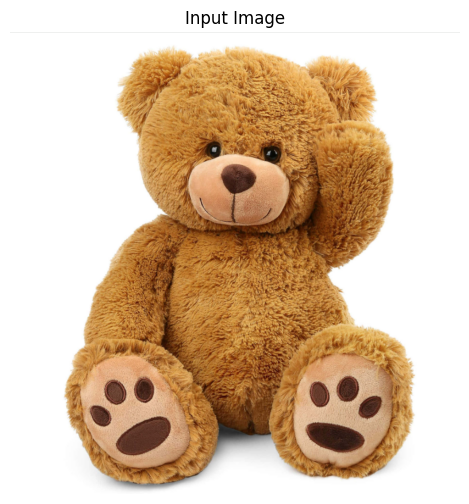


Enter a question about the uploaded image: what is the colour of the teddy ??


MULTIMODAL AI RESULT
Question: what is the colour of the teddy ??
Answer: brown


RESULT
Thus, a multimodal AI application was successfully developed using a pretrained vision-language transformer model. The system integrated an image and a text question and generated an answer based on the visual content.


In [1]:
# ============================================================
# EXPERIMENT 10
# MULTIMODAL AI USING TEXT AND IMAGE INPUTS
# ============================================================

!pip install transformers torch pillow matplotlib sentencepiece -q

import torch
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from transformers import BlipProcessor, BlipForQuestionAnswering


# ============================================================
# 1. SELECT DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)


# ============================================================
# 2. LOAD PRETRAINED BLIP MODEL
# ============================================================

model_name = "Salesforce/blip-vqa-base"

print("\nLoading BLIP model...")

processor = BlipProcessor.from_pretrained(model_name)

model = BlipForQuestionAnswering.from_pretrained(
    model_name
).to(device)


# ============================================================
# 3. UPLOAD IMAGE
# ============================================================

print("\nUpload an image for analysis:")

uploaded_files = files.upload()

image_path = next(iter(uploaded_files))

image = Image.open(image_path).convert("RGB")


# ============================================================
# 4. DISPLAY IMAGE
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(image)

plt.axis("off")

plt.title("Input Image")

plt.show()


# ============================================================
# 5. GET QUESTION FROM USER
# ============================================================

question = input(
    "\nEnter a question about the uploaded image: "
)


# ============================================================
# 6. PROCESS IMAGE AND QUESTION
# ============================================================

inputs = processor(
    images=image,
    text=question,
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}


# ============================================================
# 7. GENERATE ANSWER
# ============================================================

with torch.no_grad():

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=30
    )


# ============================================================
# 8. DECODE ANSWER
# ============================================================

answer = processor.decode(
    generated_ids[0],
    skip_special_tokens=True
)


# ============================================================
# 9. DISPLAY RESULT
# ============================================================

print("\n")
print("=" * 50)
print("MULTIMODAL AI RESULT")
print("=" * 50)

print("Question:", question)

print("Answer:", answer)


# ============================================================
# RESULT
# ============================================================

print("\n")
print("=" * 50)
print("RESULT")
print("=" * 50)

print(
    "Thus, a multimodal AI application was successfully "
    "developed using a pretrained vision-language transformer "
    "model. The system integrated an image and a text question "
    "and generated an answer based on the visual content."
)